# Telco Customer Churn — Modeling & Evaluation

**Author:** Allison Schiltz\

**Objectives**:
- Build two models to predict `Churn`:
    - For both models: **Class weights** will be used to adjust for imbalanced data and **regularization** will be used to prevent overfitting.
    - **Logistic Regression** with regularization as a baseline and for interpretability. A baseline model helps determine whether a more complex model adds value. 
    - **Gradient Boosted Trees** using LightGBM for higher predictive power
    - **Optuna** will be using for hyperparameter tuning and cross-validation
- **Strategy**: 
    - Use a train/test split strategy with cross-validation (CV) plus a final holdout set.
    - Perform cross-validation on the training data to tune hyperparameters.
    - Evaluate the final model on the untouched test set (holdout) for an unbiased performance estimate.
- Prioritize **recall ≥ 0.70** and **ROC-AUC > 0.75**
    - **Recall** to identify as many customers at risk of churning as possible (minimizing false negatives). This is important in churn scenarios, where missing a potential churner can be costly for the business.
    - **ROC-AUC** to measure the model’s overall discriminative power to distinguish between churners and non-churners across all thresholds.

## 0. Environment & Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import optuna
from optuna.samplers import TPESampler
from optuna.integration import lightgbm as lgb_optuna
import optuna.integration.lightgbm as lgb_optuna

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import recall_score, roc_auc_score, precision_score, confusion_matrix, roc_curve, precision_recall_curve, make_scorer, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold


import lightgbm as lgb

SEED = 42
np.random.seed(SEED)

In [2]:
import sys
print(sys.executable)

/Users/Allison/Code/.venv/bin/python


## 1. Load Data
- Load combined, preprocessed features and target labels needed for modeling.
- Load column-role manifest (ID, target, numeric, categorical, booleans)

In [3]:
# Load Training features
X_train_final = pd.read_csv('../data/processed/X_train_final.csv')
# Load Training target
y_train = pd.read_csv('../data/processed/y_train.csv')

# Load Test features
X_test_final = pd.read_csv('../data/processed/X_test_final.csv')
# Load Test target
y_test = pd.read_csv('../data/processed/y_test.csv')

# Load column role manifest
column_roles = pd.read_csv('../references/telco_column_role_manifest.csv')

# Load pruned feature sets based on EDA findings
pruned_features_monthly_charges_bin = pd.read_csv('../data/processed/pruned_features_monthly_charges_bin.csv', header=None).squeeze().tolist()

pruned_features_internet_service = pd.read_csv('../data/processed/pruned_features_internet_service.csv', header=None).squeeze().tolist()

pruned_features_all_add_ons = pd.read_csv('../data/processed/pruned_features_all_add_ons.csv', header=None).squeeze().tolist()

In [4]:
# Clean column names to remove special JSON characters for LightGBM compatibility
import re

def clean_lgbm_feature_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r'["\\{}\[\]:,]', '_', str(col)) for col in df.columns
    ]
    return df

# Cleaned versions for LightGBM
X_train_final_clean = clean_lgbm_feature_names(X_train_final)
X_test_final_clean = clean_lgbm_feature_names(X_test_final)


In [5]:
# Extract target column

y_train = y_train['Churn']
y_test = y_test['Churn']

In [6]:
print(X_train_final_clean.shape)
print(y_train.shape, '\n')

print(X_test_final_clean.shape)
print(y_test.shape)

(5625, 41)
(5625,) 

(1407, 41)
(1407,)


In [7]:
print("X_train_final head\n", X_train_final_clean.head())
print("X_test_final head\n", X_test_final_clean.head())
print("y_train head\n", y_train.head())
print("y_test head\n", y_test.head(), '\n')
print('X_train_final_clean dtypes:', X_train_final_clean.dtypes, '\n')
print('X_test_final_clean dtypes:', X_test_final_clean.dtypes, '\n')

X_train_final head
    Unnamed_ 0    tenure  MonthlyCharges  TotalCharges  total_services_eng  \
0        1408  1.321816        0.981556      1.659900            1.269948   
1        6992 -0.267410       -0.971546     -0.562252           -0.671868   
2        3349  1.444064        0.837066      1.756104            0.784494   
3        4486 -1.204646        0.641092     -0.908326           -0.186414   
4        3535  0.669826       -0.808787     -0.101561           -0.671868   

   gender_Male  SeniorCitizen_Yes  Partner_Yes  Dependents_Yes  \
0         True              False         True            True   
1         True              False        False           False   
2        False              False         True           False   
3         True              False        False           False   
4        False              False         True           False   

   PhoneService_Yes  ...  PaymentMethod_Mailed_check  tenure_group_eng_13-24  \
0              True  ...                

## 2. Baselines
1. Majority-class baseline:
- Predict the most frequent class for all cases (e.g., always predict "No Churn").
- Calculate and record metrics: recall, precision, ROC-AUC, PR-AUC. This sets a minimum performance bar.
2. Logistic regression baseline (with regularization):
- Train a logistic regression model using default or simple regularization (e.g., L2 penalty, class_weight="balanced").
- Evaluate on the validation or test set.
- Record the same metrics: recall, precision, ROC-AUC, PR-AUC.


### Majority class baseline: all features

In [8]:
# Majority class baseline with all features
from sklearn.dummy import DummyClassifier

# Instantiate and fit dummy classifier
dummy = DummyClassifier(strategy="stratified", random_state=SEED)
dummy.fit(X_train_final_clean, y_train.values.ravel())

# Predict class labels and class probabilities
y_pred_dummy = dummy.predict(X_test_final_clean)
y_proba_dummy = dummy.predict_proba(X_test_final_clean)[:, 1]
pr_auc_dummy = average_precision_score(y_test.values.ravel(), y_proba_dummy)

# Calculate and print metrics
print("Accuracy:", round(dummy.score(X_test_final_clean, y_test), 4))
print("Recall:", round(recall_score(y_test, y_pred_dummy), 4))
print("Precision:", round(precision_score(y_test, y_pred_dummy), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_dummy), 4))
print(f"Dummy PR-AUC (Average Precision): {pr_auc_dummy:.4f}")

Accuracy: 0.6148
Recall: 0.2781
Precision: 0.2766
ROC-AUC: 0.5074
Dummy PR-AUC (Average Precision): 0.2688


### Logistic Regression — Shared CV and Hyperparameter Grid Set Up

In [9]:
# Define StratifiedKFold cross-validator (cv) for use in both Logistic Regression and LightGBM
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = "average_precision"

# Define parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],           # Regularization strength
    'penalty': ['l2', 'l1'],                 # L1 and L2 regularization types
    'solver': ['liblinear', 'saga'],               # 'liblinear' and 'saga' support L1 and L2
    'class_weight': ['balanced']       # Handle class imbalance
}

### Logistic Regression Model: All features

In [10]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting: All features

# Set up logistic regression and grid search
logreg = LogisticRegression(max_iter=1000, random_state=SEED)
grid = GridSearchCV(logreg, param_grid, scoring=scoring, cv=cv, n_jobs=-1)

# Fit on training data
grid.fit(X_train_final_clean, y_train)

# Best model
best_logreg = grid.best_estimator_


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/Allison/Code/.venv/lib/python3.11/site-pack

In [11]:
print(best_logreg)

LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000, penalty='l1',
                   random_state=42, solver='liblinear')


### Logistic Regression Model: Binned Monthly Charges

In [12]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting: Pruned features - Monthly Charges (no add-ons except Online Security)

# Subset the full training and test sets using the pruned feature list
X_train_monthly_charges_bin = X_train_final_clean[pruned_features_monthly_charges_bin]

# Set up logistic regression and grid search
monthly_charges_logreg = LogisticRegression(max_iter=1000, random_state=SEED)
monthly_charges_grid = GridSearchCV(monthly_charges_logreg, param_grid, scoring=scoring, cv=cv, n_jobs=-1)

# Fit on training data
monthly_charges_grid.fit(X_train_monthly_charges_bin, y_train)

# Best model
best_logreg_monthly_charges_bin = monthly_charges_grid.best_estimator_



In [13]:
print("Best monthly charges hyperparam for log reg model:\n", best_logreg_monthly_charges_bin)

Best monthly charges hyperparam for log reg model:
 LogisticRegression(C=1, class_weight='balanced', max_iter=1000, penalty='l1',
                   random_state=42, solver='liblinear')


### Logistic Regression Model: Internet Service (no add-ons except Online Security)

In [14]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting: Pruned features - Internet Service (no add-ons except OnlineSecurity)

# Subset the full training and test sets using the pruned feature list
X_train_internet_service = X_train_final_clean[pruned_features_internet_service]

# Set up logistic regression and grid search
internet_service_logreg = LogisticRegression(max_iter=1000, random_state=SEED)
internet_service_grid = GridSearchCV(internet_service_logreg, param_grid, scoring=scoring, cv=cv, n_jobs=-1)

# Fit on training data
internet_service_grid.fit(X_train_internet_service, y_train if isinstance(y_train, pd.Series) else y_train)

# Best model
best_logreg_internet_service = internet_service_grid.best_estimator_



In [15]:
print("Best logreg internet service hyperparameters:\n", best_logreg_internet_service)

Best logreg internet service hyperparameters:
 LogisticRegression(C=1, class_weight='balanced', max_iter=1000, penalty='l1',
                   random_state=42, solver='saga')


### Logistic Regression Model: All Add-Ons, no Internet Service

In [16]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting: Pruned features - All Add-Ons, no InternetService

# Subset the full training and test sets using the pruned feature list
X_train_all_add_ons = X_train_final_clean[pruned_features_all_add_ons]


# Set up logistic regression and grid search
all_add_ons_logreg = LogisticRegression(max_iter=1000, random_state=SEED)
all_add_ons_grid = GridSearchCV(all_add_ons_logreg, param_grid, scoring=scoring, cv=cv, n_jobs=-1)

# Fit on training data
all_add_ons_grid.fit(X_train_all_add_ons, y_train)

# Best model
best_logreg_all_add_ons = all_add_ons_grid.best_estimator_


In [17]:
print("Best logreg all add ons hyperparameters:\n", best_logreg_all_add_ons)

Best logreg all add ons hyperparameters:
 LogisticRegression(C=10, class_weight='balanced', max_iter=1000, penalty='l1',
                   random_state=42, solver='liblinear')


### Evaluate Logistic Regression Model: All features

In [18]:
# Evaluate the All Features Logistic Regression model using the best parameters
print("Results for All Features Model")
print("Best parameters:", grid.best_params_)
print("Mean cross-validated recall:", round(grid.best_score_, 4))

cv_precision = cross_val_score(best_logreg, X_train_final_clean, y_train, cv=cv, scoring='precision')

print("Mean cross-validated precision:", round(cv_precision.mean(), 4))

cv_roc_auc = cross_val_score(best_logreg, X_train_final_clean, y_train, cv=cv, scoring='roc_auc')

print("Mean cross-validated ROC-AUC:", round(cv_roc_auc.mean(), 4))

cv_pr_auc = cross_val_score(best_logreg, X_train_final_clean, y_train, cv=cv, scoring=make_scorer(average_precision_score))

print("Mean cross-validated PR-AUC (Average Precision):", round(cv_pr_auc.mean(), 4))

Results for All Features Model
Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Mean cross-validated recall: 0.6663
Mean cross-validated precision: 0.5251
Mean cross-validated ROC-AUC: 0.8492
Mean cross-validated PR-AUC (Average Precision): 0.4738


### Evaluate Logistic Regression Model: Binned Monthly Charges

In [19]:
# Evaluate the best Logistic Regression model using the best parameters
print("Results for Pruned Monthly Charges Model")
print("Best parameters:", monthly_charges_grid.best_params_)
print("Mean cross-validated recall:", round(monthly_charges_grid.best_score_, 4))

monthly_charges_cv_precision = cross_val_score(best_logreg_monthly_charges_bin, X_train_monthly_charges_bin, y_train, cv=cv, scoring='precision')

print("Mean cross-validated precision:", round(monthly_charges_cv_precision.mean(), 4))
monthly_charges_cv_roc_auc = cross_val_score(best_logreg_monthly_charges_bin, X_train_monthly_charges_bin, y_train, cv=cv, scoring='roc_auc')

print("Mean cross-validated ROC-AUC:", round(monthly_charges_cv_roc_auc.mean(), 4))

cv_pr_auc_monthly_charges = cross_val_score(best_logreg_monthly_charges_bin, X_train_monthly_charges_bin, y_train, cv=cv, scoring=make_scorer(average_precision_score))

print("Mean cross-validated PR-AUC (Average Precision):", round(cv_pr_auc_monthly_charges.mean(), 4))

Results for Pruned Monthly Charges Model
Best parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Mean cross-validated recall: 0.6412
Mean cross-validated precision: 0.5204
Mean cross-validated ROC-AUC: 0.8436
Mean cross-validated PR-AUC (Average Precision): 0.4688


### Evaluate Logistic Regression Model: Internet Service plus Online Security Add-on

In [20]:
# Evaluate the best Logistic Regression model using the best parameters
print("Results for Internet Service Model")

print("Best parameters:", internet_service_grid.best_params_)

print("Mean cross-validated recall:", round(internet_service_grid.best_score_, 4))

internet_service_cv_precision = cross_val_score(best_logreg_internet_service, X_train_internet_service, y_train, cv=cv, scoring='precision')

print("Mean cross-validated precision:", round(internet_service_cv_precision.mean(), 4))

internet_service_cv_roc_auc = cross_val_score(best_logreg_internet_service, X_train_internet_service, y_train, cv=cv, scoring='roc_auc')

print("Mean cross-validated ROC-AUC:", round(internet_service_cv_roc_auc.mean(), 4))

cv_pr_auc_internet_service = cross_val_score(best_logreg_internet_service, X_train_internet_service, y_train, cv=cv, scoring=make_scorer(average_precision_score))

print("Mean cross-validated PR-AUC (Average Precision):", round(cv_pr_auc_internet_service.mean(), 4))

Results for Internet Service Model
Best parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'saga'}
Mean cross-validated recall: 0.638
Mean cross-validated precision: 0.516
Mean cross-validated ROC-AUC: 0.8419
Mean cross-validated PR-AUC (Average Precision): 0.4665


### Evaluate Logistic Regression Model: All Add-Ons, no Internet Service

In [21]:
# Evaluate the best Logistic Regression model using the best parameters
print("Results for All Add-Ons Model")
print("Best parameters:", all_add_ons_grid.best_params_)
print("Mean cross-validated recall:", round(all_add_ons_grid.best_score_, 4))

all_add_ons_cv_precision = cross_val_score(best_logreg_all_add_ons, X_train_all_add_ons, y_train, cv=cv, scoring='precision')

print("Mean cross-validated precision:", round(all_add_ons_cv_precision.mean(), 4))

all_add_ons_cv_roc_auc = cross_val_score(best_logreg_all_add_ons, X_train_all_add_ons, y_train, cv=cv, scoring='roc_auc')

print("Mean cross-validated ROC-AUC:", round(all_add_ons_cv_roc_auc.mean(), 4))

cv_pr_auc_all_add_ons = cross_val_score(best_logreg, X_train_all_add_ons, y_train, cv=cv, scoring=make_scorer(average_precision_score))

print("Mean cross-validated PR-AUC (Average Precision):", round(cv_pr_auc_all_add_ons.mean(), 4))

Results for All Add-Ons Model
Best parameters: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Mean cross-validated recall: 0.6537
Mean cross-validated precision: 0.5255
Mean cross-validated ROC-AUC: 0.8467
Mean cross-validated PR-AUC (Average Precision): 0.4718


## 4. Advanced Models
- Tree-based gradient boosting with LightGBM
- Hyperparameter tuning (Oputuna) with cross-validation
- Early stopping / model selection criteria

In [22]:
# Set up Optuna LightGBM parameters shared across all trials, including scale_pos_weight for class imbalance and seeds for reproducibility

# compute class-imbalance ratio for LightGBM CV scale_pos_weight
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f"n_neg={n_neg}, n_pos={n_pos}, scale_pos_weight={scale_pos_weight:.2f}")

params = {
    'objective': 'binary',
    'metric': 'average_precision',  # Use average_precision for PR-AUC optimization
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'scale_pos_weight': scale_pos_weight,

    # extra seeds for reproducibility in LightGBM
    "seed": SEED,
    "feature_fraction_seed": SEED,
    "bagging_seed": SEED,
    "data_random_seed": SEED
}

study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=SEED))
callbacks = [lgb.early_stopping(stopping_rounds=50, min_delta=0.0)]



[I 2026-02-07 15:51:52,923] A new study created in memory with name: no-name-2db54e73-4a32-45d9-a228-ef291b9523a4


n_neg=4130, n_pos=1495, scale_pos_weight=2.76


### LightGBM Hyperparameter Tuning: All features

In [23]:
# LightGBM Model with Optuna Hyperparameter Tuning with Cross-Validation

# Prepare data for LightGBM (no need for label column in features)
X = X_train_final_clean  # Use cleaned DataFrame
y = y_train

# Run Optuna hyperparameter tuning with cross-validation
optuna_lgbm = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X, label=y),
    folds=cv,
    show_progress_bar=True,
    num_boost_round=1000,
    callbacks=callbacks,
    study=study
)
optuna_lgbm.run()


feature_fraction, val_score: -inf:   0%|          | 0/7 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction, val_score: 0.658497:  14%|#4        | 1/7 [00:03<00:23,  3.98s/it]

Early stopping, best iteration is:
[49]	valid's average_precision: 0.658497 + 0.0205775
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction, val_score: 0.662387:  29%|##8       | 2/7 [00:07<00:18,  3.66s/it]

Early stopping, best iteration is:
[36]	valid's average_precision: 0.662387 + 0.0167039
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction, val_score: 0.663411:  43%|####2     | 3/7 [00:10<00:14,  3.51s/it]

Early stopping, best iteration is:
[30]	valid's average_precision: 0.663411 + 0.0203023
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction, val_score: 0.663411:  57%|#####7    | 4/7 [00:14<00:10,  3.57s/it]

Early stopping, best iteration is:
[35]	valid's average_precision: 0.660213 + 0.0132901
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction, val_score: 0.663411:  71%|#######1  | 5/7 [00:17<00:07,  3.50s/it]

Early stopping, best iteration is:
[40]	valid's average_precision: 0.661963 + 0.01808
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction, val_score: 0.663411:  86%|########5 | 6/7 [00:20<00:03,  3.34s/it]

Early stopping, best iteration is:
[28]	valid's average_precision: 0.659342 + 0.0129744
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction, val_score: 0.663411: 100%|##########| 7/7 [00:24<00:00,  3.45s/it]


Early stopping, best iteration is:
[40]	valid's average_precision: 0.66172 + 0.0162274


num_leaves, val_score: 0.663411:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.663411:   5%|5         | 1/20 [00:08<02:47,  8.82s/it]

Early stopping, best iteration is:
[16]	valid's average_precision: 0.659663 + 0.0214073
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.664746:  10%|#         | 2/20 [00:11<01:31,  5.09s/it]

Early stopping, best iteration is:
[38]	valid's average_precision: 0.664746 + 0.0154862
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.667696:  15%|#5        | 3/20 [00:13<01:03,  3.73s/it]

Early stopping, best iteration is:
[40]	valid's average_precision: 0.667696 + 0.0146163


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.667696:  20%|##        | 4/20 [00:20<01:22,  5.17s/it]

Early stopping, best iteration is:
[17]	valid's average_precision: 0.651449 + 0.0196103
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.667696:  25%|##5       | 5/20 [00:21<00:51,  3.46s/it]

Early stopping, best iteration is:
[172]	valid's average_precision: 0.667618 + 0.0105353
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.667696:  30%|###       | 6/20 [00:21<00:33,  2.40s/it]

Early stopping, best iteration is:
[79]	valid's average_precision: 0.666435 + 0.0150996
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.667696:  35%|###5      | 7/20 [00:22<00:24,  1.91s/it]

Early stopping, best iteration is:
[21]	valid's average_precision: 0.662842 + 0.020394
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210:  40%|####      | 8/20 [00:23<00:18,  1.51s/it]

Early stopping, best iteration is:
[347]	valid's average_precision: 0.66921 + 0.0140541


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.669210:  45%|####5     | 9/20 [00:25<00:18,  1.64s/it]

Early stopping, best iteration is:
[17]	valid's average_precision: 0.651449 + 0.0196108
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210:  50%|#####     | 10/20 [00:27<00:18,  1.81s/it]

Early stopping, best iteration is:
[21]	valid's average_precision: 0.6597 + 0.0168949
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210:  55%|#####5    | 11/20 [00:30<00:20,  2.28s/it]

Early stopping, best iteration is:
[17]	valid's average_precision: 0.651657 + 0.0194549
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210:  60%|######    | 12/20 [00:31<00:14,  1.83s/it]

Early stopping, best iteration is:
[17]	valid's average_precision: 0.659666 + 0.0220096
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210:  65%|######5   | 13/20 [00:33<00:13,  1.88s/it]

Early stopping, best iteration is:
[15]	valid's average_precision: 0.656343 + 0.0207616
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210:  70%|#######   | 14/20 [00:34<00:09,  1.51s/it]

Early stopping, best iteration is:
[38]	valid's average_precision: 0.661054 + 0.0179279
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210:  75%|#######5  | 15/20 [00:34<00:06,  1.28s/it]

Early stopping, best iteration is:
[347]	valid's average_precision: 0.66921 + 0.0140541
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210:  80%|########  | 16/20 [00:35<00:04,  1.06s/it]

Early stopping, best iteration is:
[42]	valid's average_precision: 0.663448 + 0.0177117
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210:  85%|########5 | 17/20 [00:35<00:02,  1.12it/s]

Early stopping, best iteration is:
[54]	valid's average_precision: 0.668324 + 0.0140492
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210:  90%|######### | 18/20 [00:36<00:01,  1.15it/s]

Early stopping, best iteration is:
[15]	valid's average_precision: 0.660342 + 0.0216333
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210:  95%|#########5| 19/20 [00:37<00:00,  1.10it/s]

Early stopping, best iteration is:
[15]	valid's average_precision: 0.656926 + 0.0238265
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210: 100%|##########| 20/20 [00:38<00:00,  1.93s/it]


Early stopping, best iteration is:
[40]	valid's average_precision: 0.663526 + 0.0188116


bagging, val_score: 0.669210:   0%|          | 0/10 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
bagging, val_score: 0.669210:  10%|#         | 1/10 [00:00<00:06,  1.43it/s]

Early stopping, best iteration is:
[267]	valid's average_precision: 0.668991 + 0.0140305
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
bagging, val_score: 0.669734:  20%|##        | 2/10 [00:01<00:06,  1.15it/s]

Early stopping, best iteration is:
[367]	valid's average_precision: 0.669734 + 0.013608
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
bagging, val_score: 0.669734:  30%|###       | 3/10 [00:02<00:05,  1.39it/s]

Early stopping, best iteration is:
[271]	valid's average_precision: 0.668855 + 0.0139307
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
bagging, val_score: 0.669958:  40%|####      | 4/10 [00:02<00:04,  1.39it/s]

Early stopping, best iteration is:
[367]	valid's average_precision: 0.669958 + 0.0140485
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
bagging, val_score: 0.669958:  50%|#####     | 5/10 [00:03<00:03,  1.43it/s]

Early stopping, best iteration is:
[351]	valid's average_precision: 0.669524 + 0.014073
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
bagging, val_score: 0.669958:  60%|######    | 6/10 [00:04<00:02,  1.42it/s]

Early stopping, best iteration is:
[332]	valid's average_precision: 0.669865 + 0.0137347
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
bagging, val_score: 0.670073:  70%|#######   | 7/10 [00:05<00:02,  1.34it/s]

Early stopping, best iteration is:
[367]	valid's average_precision: 0.670073 + 0.0139577
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
bagging, val_score: 0.670073:  80%|########  | 8/10 [00:05<00:01,  1.38it/s]

Early stopping, best iteration is:
[317]	valid's average_precision: 0.669859 + 0.013975
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
bagging, val_score: 0.670073:  90%|######### | 9/10 [00:06<00:00,  1.21it/s]

Early stopping, best iteration is:
[357]	valid's average_precision: 0.669441 + 0.0141658
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
bagging, val_score: 0.670073: 100%|##########| 10/10 [00:07<00:00,  1.34it/s]


Early stopping, best iteration is:
[269]	valid's average_precision: 0.669982 + 0.0145285


feature_fraction_stage2, val_score: 0.670073:   0%|          | 0/6 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction_stage2, val_score: 0.670073:  17%|#6        | 1/6 [00:00<00:03,  1.48it/s]

Early stopping, best iteration is:
[353]	valid's average_precision: 0.669895 + 0.0137429
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction_stage2, val_score: 0.670327:  33%|###3      | 2/6 [00:01<00:02,  1.43it/s]

Early stopping, best iteration is:
[373]	valid's average_precision: 0.670327 + 0.0138375
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction_stage2, val_score: 0.670327:  50%|#####     | 3/6 [00:02<00:01,  1.51it/s]

Early stopping, best iteration is:
[327]	valid's average_precision: 0.669922 + 0.013451
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction_stage2, val_score: 0.670327:  67%|######6   | 4/6 [00:02<00:01,  1.45it/s]

Early stopping, best iteration is:
[351]	valid's average_precision: 0.669454 + 0.0139061
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction_stage2, val_score: 0.670327:  83%|########3 | 5/6 [00:03<00:00,  1.28it/s]

Early stopping, best iteration is:
[352]	valid's average_precision: 0.670078 + 0.0136328
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction_stage2, val_score: 0.670327: 100%|##########| 6/6 [00:04<00:00,  1.36it/s]


Early stopping, best iteration is:
[367]	valid's average_precision: 0.670073 + 0.0139577


regularization_factors, val_score: 0.670327:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670327:   5%|5         | 1/20 [00:00<00:13,  1.36it/s]

Early stopping, best iteration is:
[373]	valid's average_precision: 0.670327 + 0.0138375
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670327:  10%|#         | 2/20 [00:01<00:13,  1.36it/s]

Early stopping, best iteration is:
[373]	valid's average_precision: 0.670327 + 0.0138375
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670327:  15%|#5        | 3/20 [00:02<00:12,  1.36it/s]

Early stopping, best iteration is:
[373]	valid's average_precision: 0.670327 + 0.0138375
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670327:  20%|##        | 4/20 [00:03<00:12,  1.26it/s]

Early stopping, best iteration is:
[373]	valid's average_precision: 0.670327 + 0.0138375


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.670327:  25%|##5       | 5/20 [00:04<00:13,  1.08it/s]

Early stopping, best iteration is:
[373]	valid's average_precision: 0.670327 + 0.0138375
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670327:  30%|###       | 6/20 [00:05<00:12,  1.14it/s]

Early stopping, best iteration is:
[373]	valid's average_precision: 0.670327 + 0.0138375
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670327:  35%|###5      | 7/20 [00:05<00:10,  1.19it/s]

Early stopping, best iteration is:
[373]	valid's average_precision: 0.670327 + 0.0138375
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670327:  40%|####      | 8/20 [00:06<00:09,  1.24it/s]

Early stopping, best iteration is:
[373]	valid's average_precision: 0.670327 + 0.0138375
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670327:  45%|####5     | 9/20 [00:07<00:08,  1.28it/s]

Early stopping, best iteration is:
[373]	valid's average_precision: 0.670327 + 0.0138375
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670327:  50%|#####     | 10/20 [00:07<00:07,  1.32it/s]

Early stopping, best iteration is:
[373]	valid's average_precision: 0.670327 + 0.0138375
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670484:  55%|#####5    | 11/20 [00:08<00:06,  1.36it/s]

Early stopping, best iteration is:
[365]	valid's average_precision: 0.670484 + 0.0137679
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670484:  60%|######    | 12/20 [00:09<00:06,  1.27it/s]

Early stopping, best iteration is:
[354]	valid's average_precision: 0.670069 + 0.013527
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670484:  65%|######5   | 13/20 [00:10<00:05,  1.29it/s]

Early stopping, best iteration is:
[367]	valid's average_precision: 0.670411 + 0.0137729
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670484:  70%|#######   | 14/20 [00:10<00:04,  1.34it/s]

Early stopping, best iteration is:
[354]	valid's average_precision: 0.67007 + 0.0135256
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670484:  75%|#######5  | 15/20 [00:11<00:03,  1.36it/s]

Early stopping, best iteration is:
[373]	valid's average_precision: 0.670327 + 0.0138375
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670484:  80%|########  | 16/20 [00:12<00:02,  1.38it/s]

Early stopping, best iteration is:
[358]	valid's average_precision: 0.670226 + 0.0135239
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670484:  85%|########5 | 17/20 [00:13<00:02,  1.22it/s]

Early stopping, best iteration is:
[373]	valid's average_precision: 0.670328 + 0.0138371
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670484:  90%|######### | 18/20 [00:14<00:01,  1.15it/s]

Early stopping, best iteration is:
[373]	valid's average_precision: 0.670328 + 0.0138371
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670484:  95%|#########5| 19/20 [00:15<00:00,  1.18it/s]

Early stopping, best iteration is:
[373]	valid's average_precision: 0.670328 + 0.0138371
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670484: 100%|##########| 20/20 [00:16<00:00,  1.24it/s]


Early stopping, best iteration is:
[367]	valid's average_precision: 0.670426 + 0.0137827


min_child_samples, val_score: 0.670484:   0%|          | 0/5 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
min_child_samples, val_score: 0.670484:  20%|##        | 1/5 [00:00<00:02,  1.44it/s]

Early stopping, best iteration is:
[320]	valid's average_precision: 0.669687 + 0.0139152
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
min_child_samples, val_score: 0.670484:  40%|####      | 2/5 [00:01<00:02,  1.20it/s]

Early stopping, best iteration is:
[347]	valid's average_precision: 0.670156 + 0.013852
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
min_child_samples, val_score: 0.670484:  60%|######    | 3/5 [00:03<00:02,  1.45s/it]

Early stopping, best iteration is:
[400]	valid's average_precision: 0.670229 + 0.0136415
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
min_child_samples, val_score: 0.670484:  80%|########  | 4/5 [00:04<00:01,  1.22s/it]

Early stopping, best iteration is:
[375]	valid's average_precision: 0.670189 + 0.0134345
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
min_child_samples, val_score: 0.670484: 100%|##########| 5/5 [00:05<00:00,  1.12s/it]

Early stopping, best iteration is:
[358]	valid's average_precision: 0.670258 + 0.0137571


In [24]:

print("LightGBM: All features")
print("Best params:", optuna_lgbm.best_params)

best_lgbm = lgb.LGBMClassifier(**optuna_lgbm.best_params, random_state=SEED)

y = y_train

cv_recall = cross_val_score(best_lgbm, X_train_final_clean, y, cv=cv, scoring="recall")
cv_precision = cross_val_score(best_lgbm, X_train_final_clean, y, cv=cv, scoring="precision")
cv_roc_auc = cross_val_score(best_lgbm, X_train_final_clean, y, cv=cv, scoring="roc_auc")
cv_pr_auc = cross_val_score(best_lgbm, X_train_final_clean, y, cv=cv, scoring="average_precision")

print("Mean cross-validated recall:", round(cv_recall.mean(), 4))
print("Mean cross-validated precision:", round(cv_precision.mean(), 4))
print("Mean cross-validated ROC-AUC:", round(cv_roc_auc.mean(), 4))
print("Mean cross-validated PR-AUC (Average Precision):", round(cv_pr_auc.mean(), 4))

LightGBM: All features
Best params: {'objective': 'binary', 'metric': 'average_precision', 'verbosity': -1, 'boosting_type': 'gbdt', 'scale_pos_weight': 2.762541806020067, 'seed': 42, 'feature_fraction_seed': 42, 'bagging_seed': 42, 'data_random_seed': 42, 'feature_pre_filter': False, 'lambda_l1': 3.1468553833656746e-07, 'lambda_l2': 0.01882192632598993, 'num_leaves': 2, 'feature_fraction': 0.45199999999999996, 'bagging_fraction': 0.9912288506024215, 'bagging_freq': 1, 'min_child_samples': 20}
Mean cross-validated recall: 0.8254
Mean cross-validated precision: 0.5085
Mean cross-validated ROC-AUC: 0.8467
Mean cross-validated PR-AUC (Average Precision): 0.6602


### LightGBM Model: Monthy Charges Pruned Feature Set


In [25]:
# Create pruned feature set for Monthly Charges
X_train_monthly_charges =  X_train_final_clean[pruned_features_monthly_charges_bin]
y = y_train

optuna_lgbm_monthly_charges = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X_train_monthly_charges, label=y),
    folds=cv,
    show_progress_bar=True,
    num_boost_round=1000,
    callbacks=callbacks,
    study=study
)
optuna_lgbm_monthly_charges.run()


  0%|          | 0/5 [00:00<?, ?it/s]


In [26]:
# Get best parameters and best score for LightGBM monthly charges model

print('LightGBM monthly charges model')
print('Best params:', optuna_lgbm_monthly_charges.best_params)

# Cross-validated recall, precision, and ROC-AUC for LightGBM (using best Optuna params)
best_lgbm_monthly_charges = lgb.LGBMClassifier(**optuna_lgbm_monthly_charges.best_params, random_state=SEED)

cv_recall_monthly_charges = cross_val_score(best_lgbm_monthly_charges, X_train_monthly_charges, y_train, cv=cv, scoring='recall')

cv_precision_monthly_charges = cross_val_score(best_lgbm_monthly_charges, X_train_monthly_charges, y_train, cv=cv, scoring='precision')

cv_roc_auc_monthly_charges = cross_val_score(best_lgbm_monthly_charges, X_train_monthly_charges, y_train, cv=cv, scoring='roc_auc')

cv_pr_auc_monthly_charges = cross_val_score(best_lgbm_monthly_charges, X_train_monthly_charges, y_train, cv=cv, scoring="average_precision")

print('Mean cross-validated recall:', round(cv_recall_monthly_charges.mean(), 4))
print('Mean cross-validated precision:', round(cv_precision_monthly_charges.mean(), 4))
print('Mean cross-validated ROC-AUC:', round(cv_roc_auc_monthly_charges.mean(), 4))
print("Mean cross-validated PR-AUC (Average Precision):", round(cv_pr_auc_monthly_charges.mean(), 4))


LightGBM monthly charges model
Best params: {'objective': 'binary', 'metric': 'average_precision', 'verbosity': -1, 'boosting_type': 'gbdt', 'scale_pos_weight': 2.762541806020067, 'seed': 42, 'feature_fraction_seed': 42, 'bagging_seed': 42, 'data_random_seed': 42, 'feature_pre_filter': False, 'lambda_l1': 3.1468553833656746e-07, 'lambda_l2': 0.01882192632598993, 'num_leaves': 2, 'feature_fraction': 0.45199999999999996, 'bagging_fraction': 0.9912288506024215, 'bagging_freq': 1, 'min_child_samples': 20}
Mean cross-validated recall: 0.8154
Mean cross-validated precision: 0.4976
Mean cross-validated ROC-AUC: 0.8366
Mean cross-validated PR-AUC (Average Precision): 0.6237


### LightGBM Model: Internet Service Pruned Feature Set

In [27]:
X_train_internet_service =  X_train_final_clean[pruned_features_internet_service] # Create pruned feature set for Monthly Charges
y = y_train

optuna_lgbm_internet_service = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X_train_internet_service, label=y),
    folds=cv,  # None uses StratifiedKFold by default
    show_progress_bar=True,
    num_boost_round=1000,
    callbacks=callbacks,
    study=study
)
optuna_lgbm_internet_service.run()


  0%|          | 0/5 [00:00<?, ?it/s]


In [28]:
# Get best parameters and best score for LightGBM internet service model

print('LightGBM: Internet Service Model')
print('Best params:', optuna_lgbm_internet_service.best_params)

# Cross-validated recall, precision, and ROC-AUC for LightGBM (using best Optuna params)
best_lgbm_internet_service = lgb.LGBMClassifier(**optuna_lgbm_internet_service.best_params, random_state=SEED)

cv_recall_internet_service = cross_val_score(best_lgbm_internet_service, X_train_internet_service, y_train, cv=cv, scoring='recall')

cv_precision_internet_service = cross_val_score(best_lgbm_internet_service, X_train_internet_service, y_train, cv=cv, scoring='precision')

cv_roc_auc_internet_service = cross_val_score(best_lgbm_internet_service, X_train_internet_service, y_train, cv=cv, scoring='roc_auc')

cv_pr_auc_internet_service = cross_val_score(best_lgbm_internet_service, X_train_internet_service, y_train, cv=cv, scoring="average_precision")

print('Mean cross-validated recall:', round(cv_recall_internet_service.mean(), 4))
print('Mean cross-validated precision:', round(cv_precision_internet_service.mean(), 4))
print('Mean cross-validated ROC-AUC:', round(cv_roc_auc_internet_service.mean(), 4))
print("Mean cross-validated PR-AUC (Average Precision):", round(cv_pr_auc_internet_service.mean(), 4))

LightGBM: Internet Service Model
Best params: {'objective': 'binary', 'metric': 'average_precision', 'verbosity': -1, 'boosting_type': 'gbdt', 'scale_pos_weight': 2.762541806020067, 'seed': 42, 'feature_fraction_seed': 42, 'bagging_seed': 42, 'data_random_seed': 42, 'feature_pre_filter': False, 'lambda_l1': 3.1468553833656746e-07, 'lambda_l2': 0.01882192632598993, 'num_leaves': 2, 'feature_fraction': 0.45199999999999996, 'bagging_fraction': 0.9912288506024215, 'bagging_freq': 1, 'min_child_samples': 20}
Mean cross-validated recall: 0.8167
Mean cross-validated precision: 0.4976
Mean cross-validated ROC-AUC: 0.8338
Mean cross-validated PR-AUC (Average Precision): 0.6129


In [29]:
# Create pruned feature set for Monthly Charges
X_train_all_add_ons =  X_train_final_clean[pruned_features_all_add_ons]
y = y_train

optuna_lgbm_all_add_ons = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X_train_all_add_ons, label=y),
    folds=cv,
    show_progress_bar=True,
    num_boost_round=1000,
    callbacks=callbacks,
    study=study
)

optuna_lgbm_all_add_ons.run()


  0%|          | 0/5 [00:00<?, ?it/s]


In [30]:
# Get best parameters and best score for LightGBM All Add-Ons model
print('LightGBM All Add-Ons model')
print('Best params:', optuna_lgbm_all_add_ons.best_params)

# Cross-validated recall, precision, and ROC-AUC for LightGBM (using best Optuna params)
best_lgbm_all_add_ons = lgb.LGBMClassifier(**optuna_lgbm_all_add_ons.best_params, random_state=SEED)

cv_recall_all_add_ons = cross_val_score(best_lgbm_all_add_ons, X_train_all_add_ons, y_train, cv=cv, scoring='recall')

cv_precision_all_add_ons = cross_val_score(best_lgbm_all_add_ons, X_train_all_add_ons, y_train, cv=cv, scoring='precision')

cv_roc_auc_all_add_ons = cross_val_score(best_lgbm_all_add_ons, X_train_all_add_ons, y_train, cv=cv, scoring='roc_auc')

cv_pr_auc_all_add_ons = cross_val_score(best_lgbm_all_add_ons, X_train_all_add_ons, y_train, cv=cv, scoring="average_precision")

print('Mean cross-validated recall:', round(cv_recall_all_add_ons.mean(), 4))
print('Mean cross-validated precision:', round(cv_precision_all_add_ons.mean(), 4))
print('Mean cross-validated ROC-AUC:', round(cv_roc_auc_all_add_ons.mean(), 4))
print("Mean cross-validated PR-AUC (Average Precision):", round(cv_pr_auc_all_add_ons.mean(), 4))

LightGBM All Add-Ons model
Best params: {'objective': 'binary', 'metric': 'average_precision', 'verbosity': -1, 'boosting_type': 'gbdt', 'scale_pos_weight': 2.762541806020067, 'seed': 42, 'feature_fraction_seed': 42, 'bagging_seed': 42, 'data_random_seed': 42, 'feature_pre_filter': False, 'lambda_l1': 3.1468553833656746e-07, 'lambda_l2': 0.01882192632598993, 'num_leaves': 2, 'feature_fraction': 0.45199999999999996, 'bagging_fraction': 0.9912288506024215, 'bagging_freq': 1, 'min_child_samples': 20}
Mean cross-validated recall: 0.8114
Mean cross-validated precision: 0.4982
Mean cross-validated ROC-AUC: 0.8365
Mean cross-validated PR-AUC (Average Precision): 0.628


## 5. Evaluation
-  Model quality (threshold-free) 
    - Compare ROC-AUC and PR-AUC (Average Precision) to answer: “Which model is better at ranking churn risk overall?”
- Business-operating performance (constraint-based)
    - Tune thresholds to achieve recall ≥ 0.70, while monitoring precision
    - Compare models under the actual decision rule, in this case, maximize recall with precision ≥ 0.50.

- Compare model performance on the validation set, prioritizing recall
- Plot ROC and Precision–Recall curves to visualize trade-offs
- Display confusion matrices at selected thresholds




**Majority Class Baseline (Stratified Dummy Classifier): All Features**
- Recall: 0.2781
- Precision: 0.2766
- ROC-AUC: 0.5074

### Evaluation of Logistic Regression and LightGBM models with without threshold constraint


In [67]:
# safer scorers (avoid divide-by-zero warnings if a fold predicts no positives)
precision_scorer = make_scorer(precision_score, zero_division=0)
recall_scorer = make_scorer(recall_score)

def cv_metrics_row(name, estimator, X, y, cv):
    y_1d = np.asarray(y).ravel()

    recall = cross_val_score(estimator, X, y_1d, cv=cv, scoring=recall_scorer)
    precision = cross_val_score(estimator, X, y_1d, cv=cv, scoring=precision_scorer)
    roc_auc = cross_val_score(estimator, X, y_1d, cv=cv, scoring="roc_auc")
    ap = cross_val_score(estimator, X, y_1d, cv=cv, scoring="average_precision")

    return {
        "Model": name,
        "Recall": recall.mean(),
        "Precision": precision.mean(),
        "ROC-AUC": roc_auc.mean(),
        "PR-AUC (AP)": ap.mean(),  
        "Recall_std": recall.std(),
        "Precision_std": precision.std(),
        "ROC-AUC_std": roc_auc.std(),
        "PR-AUC (AP)_std": ap.std(),
    }

# Define all models + their feature matrices (use the SAME cv for fairness)
models_to_compare = [
    ("Logistic Regression: All Features", best_logreg, X_train_final_clean),
    ("Logistic Regression: Monthly Charges", best_logreg_monthly_charges_bin, X_train_monthly_charges_bin),
    ("Logistic Regression: Internet Service", best_logreg_internet_service, X_train_internet_service),
    ("Logistic Regression: All Add-Ons", best_logreg_all_add_ons, X_train_all_add_ons),

    ("LightGBM: All Features", best_lgbm, X_train_final_clean),
    ("LightGBM: Monthly Charges", best_lgbm_monthly_charges, X_train_monthly_charges),
    ("LightGBM: Internet Service", best_lgbm_internet_service, X_train_internet_service),
    ("LightGBM: All Add-Ons", best_lgbm_all_add_ons, X_train_all_add_ons)
]

rows = [cv_metrics_row(name, est, X, y_train, cv) for name, est, X in models_to_compare]
df_compare = pd.DataFrame(rows)

print('Comparison of Logistic Regression and LightGBM models with different feature sets:')

df_display = (
    df_compare[["Model", "Recall", "Precision", "ROC-AUC", "PR-AUC (AP)"]]
    .set_index("Model")
    .sort_values("Recall", ascending=False)
    .round(4)
)
df_display

Comparison of Logistic Regression and LightGBM models with different feature sets:


,Recall,Precision,ROC-AUC,PR-AUC (AP)
Model,,,,
LightGBM: All Features,0.8254,0.5085,0.8467,0.6602
LightGBM: Internet Service,0.8167,0.4976,0.8338,0.6129
LightGBM: Monthly Charges,0.8154,0.4976,0.8366,0.6237
LightGBM: All Add-Ons,0.8114,0.4982,0.8365,0.6280
Logistic Regression: All Add-Ons,0.8033,0.5255,0.8467,0.6537
Logistic Regression: All Features,0.8020,0.5251,0.8492,0.6663
Logistic Regression: Internet Service,0.8020,0.5160,0.8419,0.6380
Logistic Regression: Monthly Charges,0.7973,0.5204,0.8436,0.6412


### Evaluation of Logistic Regression and LightGBM models with threshold constraint


In [64]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold

lgbm_cal = CalibratedClassifierCV(best_lgbm_all_add_ons, method="sigmoid", cv=cv)
logreg_cal = CalibratedClassifierCV(best_logreg_all_add_ons, method="sigmoid", cv=cv)

# Then feed lgbm_cal / logreg_cal into your existing oof_constraint_threshold_row(...)

In [68]:

def oof_constraint_threshold_row(name, estimator, X, y, cv, *, min_precision=0.50):
    """
    OOF (out-of-fold) threshold selection for: maximize recall subject to precision >= min_precision.

    Returns one row (dict) you can append into a comparison table.
    """
    y_1d = np.asarray(y).ravel()

    # OOF probabilities for the positive class
    oof_proba = cross_val_predict(
        estimator,
        X,
        y_1d,
        cv=cv,
        method="predict_proba",
    )[:, 1]

    # Threshold-free metrics (computed once)
    oof_roc = roc_auc_score(y_1d, oof_proba)
    oof_ap = average_precision_score(y_1d, oof_proba)

    # Threshold search using PR curve
    precision, recall, thresholds = precision_recall_curve(y_1d, oof_proba)
    precision_t = precision[:-1]  # aligned to thresholds
    recall_t = recall[:-1]

    valid = precision_t >= min_precision

    if not np.any(valid):
        return {
            "Model": name,
            "Meets constraint?": False,
            "Chosen threshold": np.nan,
            "Precision@thresh (OOF)": np.nan,
            "Recall@thresh (OOF)": np.nan,
            "ROC-AUC (OOF)": oof_roc,
            "PR-AUC/AP (OOF)": oof_ap,
            "min_precision": min_precision,
        }

    # Among thresholds that meet precision constraint, pick the one with max recall
    best_idx = np.argmax(recall_t[valid])
    chosen_thr = thresholds[valid][best_idx]

    # Compute actual precision/recall at that chosen threshold
    y_pred = (oof_proba >= chosen_thr).astype(int)
    prec_at = precision_score(y_1d, y_pred, zero_division=0)
    rec_at = recall_score(y_1d, y_pred)

    return {
        "Model": name,
        "Meets constraint?": True,
        "Chosen threshold": float(chosen_thr),
        "Precision@thresh (OOF)": float(prec_at),
        "Recall@thresh (OOF)": float(rec_at),
        "ROC-AUC (OOF)": float(oof_roc),
        "PR-AUC/AP (OOF)": float(oof_ap),
        "min_precision": float(min_precision),
    }


MIN_PRECISION = 0.50

models_to_compare = [
    ("Logistic Regression: All Features", best_logreg, X_train_final_clean),
    ("Logistic Regression: Monthly Charges", best_logreg_monthly_charges_bin, X_train_monthly_charges_bin),
    ("Logistic Regression: Internet Service", best_logreg_internet_service, X_train_internet_service),
    ("Logistic Regression: All Add-Ons", best_logreg_all_add_ons, X_train_all_add_ons),

    ("LightGBM: All Features", best_lgbm, X_train_final_clean),
    ("LightGBM: Monthly Charges", best_lgbm_monthly_charges, X_train_monthly_charges),
    ("LightGBM: Internet Service", best_lgbm_internet_service, X_train_internet_service),
    ("LightGBM: All Add-Ons", best_lgbm_all_add_ons, X_train_all_add_ons),
    ("LightGBM: All Add-Ons (Calibrated)", lgbm_cal, X_train_all_add_ons),
    ("Logistic Regression: All Add-Ons (Calibrated)", logreg_cal, X_train_all_add_ons)
]

rows = [
    oof_constraint_threshold_row(name, est, X, y_train, cv, min_precision=MIN_PRECISION)
    for name, est, X in models_to_compare
]

df_constraint = pd.DataFrame(rows)

print('Comparison of Logistic Regression and LightGBM models with threshold constraints:')


# Nice display ordering (constraint-first, then best recall)
df_constraint_display = (
    df_constraint
    .sort_values(["Meets constraint?", "Recall@thresh (OOF)"], ascending=[False, False])
    .reset_index(drop=True)
    [["Model", "Meets constraint?", "Chosen threshold", "Recall@thresh (OOF)", "Precision@thresh (OOF)", "ROC-AUC (OOF)", "PR-AUC/AP (OOF)"]]
    .round(4)
)

df_constraint_display

Comparison of Logistic Regression and LightGBM models with threshold constraints:


,Model,Meets constraint?,Chosen threshold,Recall@thresh (OOF),Precision@thresh (OOF),ROC-AUC (OOF),PR-AUC/AP (OOF)
0,Logistic Regression: All Add-Ons,True,0.4531,0.8428,0.5000,0.8463,0.6500
1,Logistic Regression: All Add-Ons (Calibrated),True,0.2347,0.8428,0.5000,0.8463,0.6497
2,LightGBM: All Features,True,0.4712,0.8421,0.5000,0.8462,0.6569
3,Logistic Regression: All Features,True,0.4587,0.8408,0.5000,0.8487,0.6627
4,Logistic Regression: Monthly Charges,True,0.4551,0.8341,0.5000,0.8432,0.6390
5,Logistic Regression: Internet Service,True,0.4582,0.8288,0.5000,0.8417,0.6349
6,LightGBM: Internet Service,True,0.5039,0.8167,0.5000,0.8332,0.6158
7,LightGBM: All Add-Ons (Calibrated),True,0.2524,0.8120,0.5000,0.8364,0.6291
8,LightGBM: Monthly Charges,True,0.5049,0.8114,0.5004,0.8360,0.6246
9,LightGBM: All Add-Ons,True,0.5039,0.8114,0.5000,0.8360,0.6260


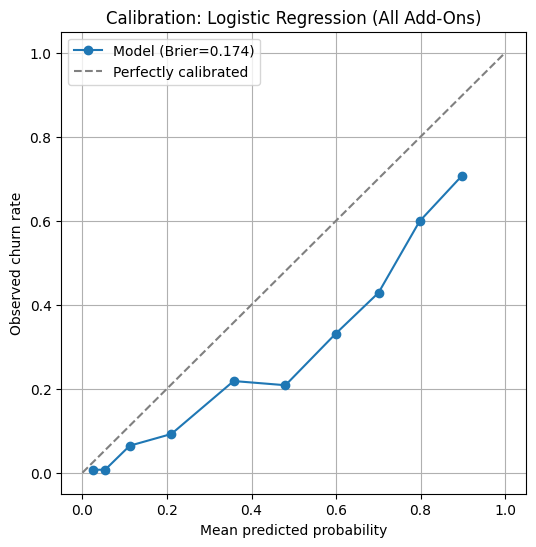

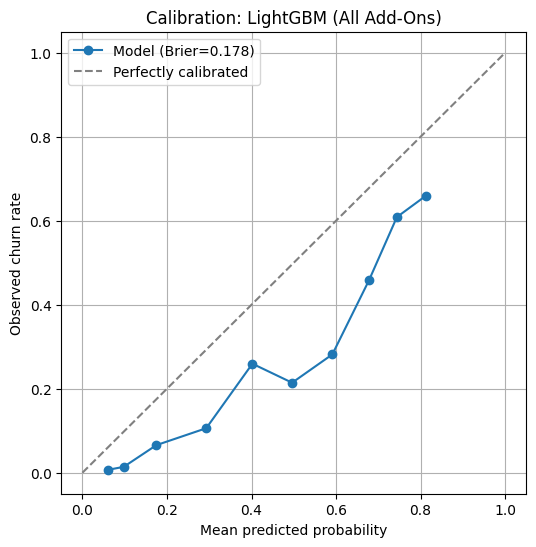

{'brier': 0.1780829707114729,
 'mean_pred': array([0.06117204, 0.09776288, 0.17496161, 0.29293901, 0.40209851,
        0.49604428, 0.59123101, 0.67774558, 0.74394389, 0.81269716]),
 'frac_pos': array([0.00704225, 0.01398601, 0.06569343, 0.10596026, 0.25954198,
        0.21428571, 0.28169014, 0.45774648, 0.60869565, 0.65957447])}

In [60]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

def plot_calibration_curve(estimator, X_train, y_train, X_eval, y_eval, *,
                           n_bins=10, strategy="quantile", title=None, save_path=None):
    y_train_1d = np.asarray(y_train).ravel()
    y_eval_1d = np.asarray(y_eval).ravel()

    estimator.fit(X_train, y_train_1d)
    proba = estimator.predict_proba(X_eval)[:, 1]

    frac_pos, mean_pred = calibration_curve(
        y_eval_1d, proba, n_bins=n_bins, strategy=strategy
    )

    brier = brier_score_loss(y_eval_1d, proba)

    plt.figure(figsize=(6, 6))
    plt.plot(mean_pred, frac_pos, marker="o", label=f"Model (Brier={brier:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed churn rate")
    plt.title(title or "Calibration plot (reliability curve)")
    plt.grid(True)
    plt.legend()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()

    return {"brier": brier, "mean_pred": mean_pred, "frac_pos": frac_pos}

# Example usage:
# Logistic Regression
plot_calibration_curve(
    best_logreg_all_add_ons,
    X_train_all_add_ons, y_train,
    X_test_all_add_ons, y_test,
    title="Calibration: Logistic Regression (All Add-Ons)",
    save_path="../reports/figures/calibration_logreg_all_add_ons.png"
)

# LightGBM
plot_calibration_curve(
    best_lgbm_all_add_ons,
    X_train_all_add_ons, y_train,
    X_test_all_add_ons, y_test,
    title="Calibration: LightGBM (All Add-Ons)",
    save_path="../reports/figures/calibration_lgbm_all_add_ons.png"
)

### Model Selection Rationale: Focusing on Logistic Regression All Add-Ons Feature Set
The Logistic Regression: All Add-Ons model achieves ...

Rationale:

- 

In [59]:
# Calculate confusion matrix on training data using out-of-fold predictions for Logistic Regression All Add-Ons Model

y_train_1d = np.asarray(y_train).ravel()

oof_proba = cross_val_predict(
    best_logreg_all_add_ons,
    X_train_all_add_ons,
    y_train_1d,
    cv=cv,
    method="predict_proba"
)[:, 1]

y_pred_oof = (oof_proba >= 0.5).astype(int)
cm_oof = confusion_matrix(y_train_1d, y_pred_oof)
print("Confusion Matrix - LogReg (All Add-Ons, thr=0.5, OOF train):\n", cm_oof)



Confusion Matrix - LogReg (All Add-Ons, thr=0.5, OOF train):
 [[3045 1085]
 [ 294 1201]]


**Notes:**

Businesses typically aim to identify at least 70% of actual churners (recall ≥ 0.7) and prefer that at least half of the customers flagged as churners actually do churn (precision ≥ 0.5). I focused on the threshold that met these criteria, which is why the XXX probability threshold was selected for evaluation. 

In practice, the optimal model choice may depend on additional business factors, such as the relative costs of customer churn versus retention offers, which are not specified here.

## 6. Final Model Testing
- Retrain final model on entire training dataset using best hyperparameters and preprocessing
- Evaluate on untouched test set
- Report final metrics (recall, precision, ROC-AUC)


### Retrain Logistic Regression All Add-Ons model on full training data with best hyperparameters

In [34]:
# Best parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

final_logreg_all_add_ons = LogisticRegression(
    **internet_service_grid.best_params_,
    max_iter=1000,
    random_state=SEED
)
final_logreg_all_add_ons.fit(X_train_all_add_ons, y_train)


,penalty,'l1'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'saga'
,max_iter,1000
,multi_class,'deprecated'


### Predict on All Add-Ons test set and apply threshold

In [35]:
# Predictions on test set
X_test_all_add_ons = X_test_final_clean[pruned_features_all_add_ons]

y_pred_final_logreg_all_add_ons = final_logreg_all_add_ons.predict(X_test_all_add_ons)
y_proba_final_logreg_all_add_ons = final_logreg_all_add_ons.predict_proba(X_test_all_add_ons)[:, 1]


# Apply 0.5 threshold
y_pred_final_logreg_all_add_ons = (y_proba_final_logreg_all_add_ons >= 0.5).astype(int)

### Evaluate Internet Service Logistic Regression model on test set

In [36]:
# Compare predictions to true labels--All Add-Ons Model
recall_all_add_ons = recall_score(y_test, y_pred_final_logreg_all_add_ons)
precision_all_add_ons = precision_score(y_test, y_pred_final_logreg_all_add_ons)
roc_auc_all_add_ons = roc_auc_score(y_test, y_proba_final_logreg_all_add_ons)
cm_all_add_ons = confusion_matrix(y_test, y_pred_final_logreg_all_add_ons)

print(f"Recall Final All Add-Ons Model: {recall_all_add_ons:.3f}")
print(f"Precision Final All Add-Ons Model: {precision_all_add_ons:.3f}")
print(f"ROC-AUC Final All Add-Ons Model: {roc_auc_all_add_ons:.3f}")
print("Confusion Matrix Final All Add-Ons Model:")
print(cm_all_add_ons)

Recall Final All Add-Ons Model: 0.807
Precision Final All Add-Ons Model: 0.496
ROC-AUC Final All Add-Ons Model: 0.835
Confusion Matrix Final All Add-Ons Model:
[[726 307]
 [ 72 302]]


### Display row-normalized confusion matrix for All Add-Ons logistic regression model

In [37]:
def confusion_matrix_percentages(cm):
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    return pd.DataFrame(
        cm_pct,
        index=['Actual Negative', 'Actual Positive'],
        columns=['Predicted Negative', 'Predicted Positive']
    )

cm_pct_all_add_ons = confusion_matrix_percentages(cm_all_add_ons)

print("Confusion Matrix (% actual class, row-normalized) - Final All Add-Ons Logistic Regression (0.5 threshold, test set):")
display(cm_pct_all_add_ons)

Confusion Matrix (% actual class, row-normalized) - Final All Add-Ons Logistic Regression (0.5 threshold, test set):


,Predicted Negative,Predicted Positive
Actual Negative,70.280736,29.719264
Actual Positive,19.251337,80.748663


### Comparison of Validation and Test Set Performance for Final Logistic Regression Model

The table below summarizes key metrics at the 0.50 probability threshold, comparing the model’s performance on the validation set (cross-validated training data) to its performance on the holdout test set after retraining on the full training data. This allows for an assessment of model generalization and consistency across data splits.

**Note on terminology:**
- The "validation set" refers to the portion of the training data used during cross-validation to tune hyperparameters and select the best model. These results reflect model performance during development, before seeing the test set.
- The "test set" (also called the holdout set) is a separate, untouched dataset set aside at the start of the project. It is only used for the final evaluation after all model selection and tuning are complete, providing an unbiased estimate of real-world performance.

**Table of Validation and Test Set Metrics**

| Metric                                | Validation Set | Test Set |
|---------------------------------------|----------------|----------|
|Recall                                 | 0.8094            | 0.797     |
|Precision                              | 0.5290            | 0.492     |
|ROC-AUC                                | 0.8469           | 0.835    |
|Confusion Matrix (% of actual class)   |                 |          |
|    - True Neg (TN)                    | 73.9           | 70.18      |
|    - False Pos (FP)                   | 26.1           | 29.82      |
|    - False Neg (FN)                   | 18.26           | 20.32      |
|    - True Pos (TP)                    | 81.74           | 79.68      |

**Summary**:
- The model generalizes well—there’s no sign of severe overfitting.
- The small drop in precision and recall is expected when moving from validation to test data.
- These differences are minor and within the range of normal variation.


### Determine the most important features for final Internet Service logistic regression model

In [38]:
# Determine most important predictors for final Internet Service logistic regression model

# Get feature names and coefficients
feature_names_all_add_ons = X_train_all_add_ons.columns
coefs_all_add_ons = final_logreg_all_add_ons.coef_.flatten()

# Create DataFrame of features and coefficients
coef_df_all_add_ons = pd.DataFrame({
    'feature': feature_names_all_add_ons,
    'coefficient': coefs_all_add_ons,
    'abs_coefficient': np.abs(coefs_all_add_ons)
})

# Sort by absolute value of coefficient (importance)
coef_df_all_add_ons = coef_df_all_add_ons.sort_values('abs_coefficient', ascending=False)

In [39]:
# Load the column manifest with readable labels
manifest = pd.read_csv('../references/telco_column_role_manifest_with_labels.csv')

# Create a mapping: feature code → readable label
# Adjust column names as needed based on your manifest structure
feature_map = dict(zip(manifest['column_name'], manifest['readable_label']))

# Map features in coef_df to readable labels
coef_df_all_add_ons['readable_label'] = coef_df_all_add_ons['feature'].map(feature_map).fillna(coef_df_all_add_ons['feature'])

# Display top predictors with readable labels
print(coef_df_all_add_ons[['readable_label', 'coefficient', 'abs_coefficient']].head(10))

# Save the top predictors with readable labels as a CSV file
coef_df_all_add_ons[['readable_label', 'coefficient', 'abs_coefficient']].to_csv(
    '../reports/top_predictors_logreg_all_add_ons.csv', index=False
)

                     readable_label  coefficient  abs_coefficient
17                Contract_Two_year    -1.820148         1.820148
24        Tenure Group (49+ months)    -1.696152         1.696152
23      Tenure Group (25-48 months)    -1.487492         1.487492
22     Tenure Group (13-24  months)    -1.132000         1.132000
16            Contract 1-year (Yes)    -0.881552         0.881552
3    Internet Service (Fiber Optic)     0.861121         0.861121
25       Tenure Group (7-12 months)    -0.769284         0.769284
20  Payment Method Electronic (Yes)     0.392747         0.392747
5             Online Security (Yes)    -0.368248         0.368248
13               Streaming TV (Yes)     0.342937         0.342937


/var/folders/xk/1_94y7fn37sf7kbch2g77hlm0000gp/T/ipykernel_39565/1520250730.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='coefficient', y='readable_label', data=top_coef, palette='coolwarm', orient='h')


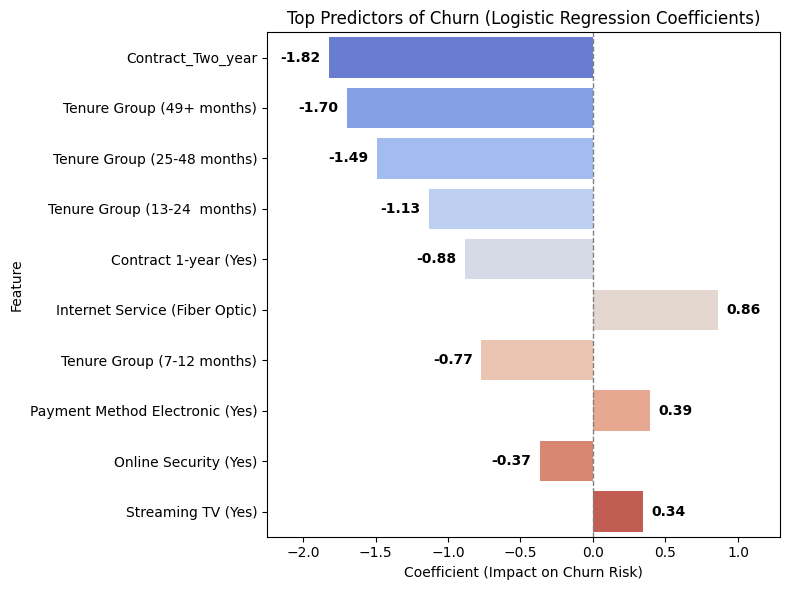

In [40]:
# Plot top predictors for churn from logistic regression model

top_n = 10
top_coef = coef_df_all_add_ons.head(top_n).copy()
plt.figure(figsize=(8, 6))  # Wide figure for more space
ax = sns.barplot(x='coefficient', y='readable_label', data=top_coef, palette='coolwarm', orient='h')
plt.title('Top Predictors of Churn (Logistic Regression Coefficients)')
plt.xlabel('Coefficient (Impact on Churn Risk)')
plt.ylabel('Feature')
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

# Set x-limits to add more space for annotation text
xlim = ax.get_xlim()
x_pad = 0.1 * (xlim[1] - xlim[0])
plt.xlim(xlim[0] - x_pad, xlim[1] + x_pad)

# Annotate each bar with its coefficient value, always outside the bar
for bar, coef in zip(ax.patches, top_coef['coefficient']):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    if x >= 0:
        text_x = x + 0.02 * (xlim[1] - xlim[0])
        ha = 'left'
    else:
        text_x = x - 0.02 * (xlim[1] - xlim[0])
        ha = 'right'
    ax.text(text_x, y, f'{coef:.2f}', va='center', ha=ha, color='black', fontsize=10, fontweight='bold', clip_on=False)

plt.tight_layout()
plt.savefig('../reports/figures/top_predictors_logreg_all_add_ons.png', bbox_inches='tight', dpi=300)
plt.show()

## 7. Interpretation of top coefficients
Of the top 10 predictors of churn, seven are negative—these are key retention factors. The remaining three are positive, indicating that customers with these characteristics are more likely to churn. It is common for churn models to identify more strong retention factors (negative coefficients) than churn factors (positive coefficients), since many features are designed to reduce churn risk, while actual churn is often triggered by a few specific issues such as high prices or poor service.

**Retention Factors**

In the final Logistic Regression All Add-Ons model, several factors stood out as most important for customer retention. As expected, customers with longer contract terms (1-year and 2-year contracts) and those who have been with the company for a longer period (tenure groups: 7-12 months, 13-24 months, 25-48 months, and 48+ months) were much less likely to churn. This makes sense because longer contracts and higher tenure typically indicate greater customer commitment and satisfaction.

The Online Security add-on service also emerged as a significant retention factor, showing the largest effect among all the add-on services. One possible explanation is that the Online Security service addresses specific customer concerns (such as data protection or internet safety), making them more satisfied and less likely to churn.

In summary, while contract length and tenure are classic retention drivers, the strong association between the Online Security add-on and lower churn highlights the importance of value-added services in customer retention strategies.

**Churn Factors**

The primary factors associated with customer churn are fiber optic internet service, electronic payment method, and multiple phone lines. These factors are distinct and likely represent different customer segments.

Fiber optic internet service relates to the type of internet technology a customer uses. Since fiber is typically marketed as a premium, high-speed option, customers who choose it often have higher expectations for reliability and performance. If their experience falls short, they may be more inclined to switch providers.

Electronic payment method refers to how customers pay for their service. The convenience and flexibility of electronic payments make it easier for customers to cancel or switch providers. Those comfortable with digital transactions may be more likely to change services when dissatisfied.

Multiple phone lines indicate a more complex or larger account, such as families or businesses. Customers managing several lines are often more attentive to costs and service quality, making them more proactive in seeking better deals or switching providers if issues arise.

To summarize, these churn factors—fiber optic internet service, electronic payment method, and multiple phone lines—reflect different aspects of customer behavior and needs. Their influence on churn highlights the importance of understanding diverse customer segments and tailoring retention strategies accordingly.



## 8. Documentation

**Model Selection Rationale and Business Implications**

The final model was chosen for its strong recall and ROC-AUC scores, emphasizing the ability to accurately identify customers at risk of churning. Recall was priorized to identify as many customers at risk of churning as possible (minimizing false negatives). This approach is especially important for the business, as failing to identify a customer likely to churn can result in lost revenue and missed opportunities for retention.

Logistic Regression was selected due to its interpretability, which makes it easier to communicate key drivers to business stakeholders. Although advanced LightGBM models were also tested, they did not outperform Logistic Regression. By incorporating both classic retention factors (such as contract length and tenure) and actionable service features (like the Online Security add-on), the model provides recommendations that are both data-driven and directly relevant to business needs.

From a business perspective, the model enables targeted retention strategies by identifying high-risk customers and the specific factors influencing their likelihood to churn. This supports more efficient allocation of retention resources and the design of tailored offers or interventions.

In the future, additional features or external data sources could be explored to improve predictive power. Resampling could be explored as a way to further improve the model.


## 9. Outputs
Save all relevant figures, tables, and processed data to the appropriate folders.

In [41]:
# Save processed datasets with cleaned column names for LightGBM
X_train_final_clean.to_csv('../data/processed/X_train_final_clean.csv', index=False)
X_test_final_clean.to_csv('../data/processed/X_test_final_clean.csv', index=False)
X_train_all_add_ons.to_csv('../data/processed/X_train_all_add_ons.csv', index=False)

# Save extracted target variables
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

In [42]:
# Create the model performance summary as a DataFrame
model_performance = pd.DataFrame({
    "Model": [
        "Logistic Regression: All Features",
        "Logistic Regression: Monthly Charges",
        "Logistic Regression: Internet Service",
        "Logistic Regression: All Add-Ons",
        "LightGBM: All Features",
        "LightGBM: Monthly Charges",
        "LightGBM: Internet Service",
        "LightGBM: All Add-Ons"
    ],
    "Recall": [0.802, 0.800, 0.804, 0.8094, 0.7973, 0.8181, 0.8013, 0.8054],
    "Precision": [0.5262, 0.5163, 0.5227, 0.5290, 0.5263, 0.497, 0.5117, 0.5195],
    "ROC-AUC": [0.8479, 0.8339, 0.8445, 0.8469, 0.8428, 0.8356, 0.8402, 0.8431]
})

# Save the DataFrame as a CSV file
model_performance.to_csv('../reports/model_performance_summary.csv', index=False)

model_performance

,Model,Recall,Precision,ROC-AUC
0,Logistic Regression: All Features,0.8020,0.5262,0.8479
1,Logistic Regression: Monthly Charges,0.8000,0.5163,0.8339
2,Logistic Regression: Internet Service,0.8040,0.5227,0.8445
3,Logistic Regression: All Add-Ons,0.8094,0.5290,0.8469
4,LightGBM: All Features,0.7973,0.5263,0.8428
5,LightGBM: Monthly Charges,0.8181,0.4970,0.8356
6,LightGBM: Internet Service,0.8013,0.5117,0.8402
7,LightGBM: All Add-Ons,0.8054,0.5195,0.8431


In [43]:
# Create the validation and test set metrics table as a DataFrame
table_metrics = pd.DataFrame({
    'Metric': [
        'Recall',
        'Precision',
        'ROC-AUC',
     ],
    'Validation Set': [
        0.8094,
        0.5290,
        0.8469,
    ],
    'Test Set': [
        0.797,
        0.492,
        0.835,
    ]
})

# Save the DataFrame as a CSV file for future use
table_metrics.to_csv('../reports/validation_test_metrics_summary.csv', index=False)

table_metrics

,Metric,Validation Set,Test Set
0,Recall,0.8094,0.797
1,Precision,0.5290,0.492
2,ROC-AUC,0.8469,0.835


In [44]:
# Create DataFrame for the confusion matrix metrics
confusion_matrix_metrics = pd.DataFrame({
    'Metric': ['True Neg (TN)', 'False Pos (FP)', 'False Neg (FN)', 'True Pos (TP)'],
    'Validation Set': [73.9, 26.1, 18.26, 81.74],
    'Test Set': [70.18, 29.82, 20.32, 79.68]
})

# Save the confusion matrix DataFrame as a CSV file
confusion_matrix_metrics.to_csv('../reports/confusion_matrix_metrics.csv', index=False)

confusion_matrix_metrics

,Metric,Validation Set,Test Set
0,True Neg (TN),73.90,70.18
1,False Pos (FP),26.10,29.82
2,False Neg (FN),18.26,20.32
3,True Pos (TP),81.74,79.68


In [45]:
# Create DataFrame for Logistic Regression (All Add-Ons) thresholds
thresholds_df = pd.DataFrame({
    'Threshold': [0.45, 0.50, 0.55, 0.60],
    'Recall': [0.84, 0.81, 0.76, 0.71],
    'Precision': [0.51, 0.53, 0.55, 0.57],
    'ROC-AUC': [0.77, 0.77, 0.77, 0.76]
})

# Save as CSV
thresholds_df.to_csv('../reports/logreg_all_add_ons_thresholds_summary.csv', index=False)
thresholds_df

,Threshold,Recall,Precision,ROC-AUC
0,0.45,0.84,0.51,0.77
1,0.50,0.81,0.53,0.77
2,0.55,0.76,0.55,0.77
3,0.60,0.71,0.57,0.76


In [46]:
# Create confusion matrix table for Logistic Regression (All Add-Ons, 0.5 threshold, training data)
conf_matrix_train = pd.DataFrame({
    'Actual': ['Negative', 'Positive'],
    'Predicted Negative': [0.738741, 0.182609],
    'Predicted Positive': [0.261259, 0.817391]
})

# Save as CSV
conf_matrix_train.to_csv('../reports/cm_logreg_all_add_ons_train_0.5_row_norm.csv', index=False)
conf_matrix_train

,Actual,Predicted Negative,Predicted Positive
0,Negative,0.738741,0.261259
1,Positive,0.182609,0.817391


In [47]:
# Fit and predict as in your code
best_logreg_all_add_ons.fit(X_train_all_add_ons, y_train)
y_proba_logreg_train = best_logreg_all_add_ons.predict_proba(X_train_all_add_ons)[:, 1]
y_pred_logreg_train = (y_proba_logreg_train >= 0.5).astype(int)
cm_logreg_train_all_add_ons = confusion_matrix(y_train, y_pred_logreg_train)

# Convert raw confusion matrix to DataFrame and save as CSV
cm_raw_df = pd.DataFrame(
    cm_logreg_train_all_add_ons,
    index=['Actual Negative', 'Actual Positive'],
    columns=['Predicted Negative', 'Predicted Positive']
)
cm_raw_df.to_csv('../reports/conf_matrix_logreg_all_add_ons_train_0.5_raw.csv')
cm_raw_df

,Predicted Negative,Predicted Positive
Actual Negative,3058,1072
Actual Positive,271,1224
